# 02 — LSTM Model Training & Evaluation
**P08: Stock Market Sentiment and Price Movement Predictor**

This notebook:
1. Prepares feature-engineered sequences for all 5 stocks.
2. Trains a stacked LSTM classifier (with LR warmup + early stopping).
3. Evaluates on the test set — accuracy, AUC-ROC, classification report.
4. Plots training/validation loss curves and the ROC curve.
5. Saves the trained weights to `results/lstm_model.pth`.

---
## 0 · Setup

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import STOCKS, LOOKBACK, EPOCHS, SEED
from src.data_pipeline import load_all_stocks
from src.feature_engineering import (
    add_features, add_target, create_sequences,
    split_data, scale_features,
)
from src.lstm_model import (
    LSTMClassifier, train_lstm, evaluate_lstm,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

Device: cpu


---
## 1 · Load & Engineer Features for All 5 Stocks

In [3]:
stock_data = load_all_stocks()

processed = {}
for ticker, df in stock_data.items():
    print(f'\n── {ticker} ──')
    df_feat = add_features(df)
    df_feat = add_target(df_feat)
    processed[ticker] = df_feat

print(f'\n✓ Processed {len(processed)} stocks.')


═══════════════════════════════════════════════════════
  Loading 5 stocks: AAPL, MSFT, GOOGL, AMZN, TSLA
═══════════════════════════════════════════════════════

[CACHE]  AAPL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AAPL_ohlcv.csv
[CACHE]  MSFT — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\MSFT_ohlcv.csv
[CACHE]  GOOGL — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\GOOGL_ohlcv.csv
[CACHE]  AMZN — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\AMZN_ohlcv.csv
[CACHE]  TSLA — loading from d:\AI_ML_NLP\P08-Stock-Sentiment-Predictor\data\TSLA_ohlcv.csv

[INFO]  Loaded 5 tickers successfully.


── AAPL ──
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 805 (54.1%)  |  ↓ 683 (45.9%)  |  Total 1488

── MSFT ──
[FEATURES]  Added 6 features → 11 columns, 1489 rows remain after NaN drop.
[TARGET]  ↑ 802 (53.9%)  |  ↓ 686 (46.1%)  |  Total 1488

── GOOGL ──
[FEATURES]  Added 6 features →

---
## 2 · Per-Stock Split & Combine into One Dataset

We split each stock **chronologically** into train/val/test *before* concatenation.  
This prevents cross-stock data leakage and preserves temporal ordering within each ticker.

In [4]:
all_X_train, all_y_train = [], []
all_X_val,   all_y_val   = [], []
all_X_test,  all_y_test  = [], []
per_stock_test = {}

for ticker, df in processed.items():
    feat_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'target']
    df_scaled, _ = scale_features(df, feat_cols)
    X, y = create_sequences(df_scaled, feature_cols=feat_cols, lookback=LOOKBACK)
    splits = split_data(X, y, train_ratio=0.70, val_ratio=0.15)
    all_X_train.append(splits['X_train'])
    all_y_train.append(splits['y_train'])
    all_X_val.append(splits['X_val'])
    all_y_val.append(splits['y_val'])
    all_X_test.append(splits['X_test'])
    all_y_test.append(splits['y_test'])
    per_stock_test[ticker] = (splits['X_test'], splits['y_test'])
    print(f'  {ticker}: train={splits["X_train"].shape[0]}  val={splits["X_val"].shape[0]}  test={splits["X_test"].shape[0]}')

X_train = np.concatenate(all_X_train, axis=0)
y_train = np.concatenate(all_y_train, axis=0)
X_val   = np.concatenate(all_X_val,   axis=0)
y_val   = np.concatenate(all_y_val,   axis=0)
X_test  = np.concatenate(all_X_test,  axis=0)
y_test  = np.concatenate(all_y_test,  axis=0)

print(f'\nCombined — X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
  AAPL: train=1020  val=219  test=219
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
  MSFT: train=1020  val=219  test=219
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
  GOOGL: train=1020  val=219  test=219
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[SPLIT]  Train 1020 | Val 219 | Test 219 (ratio 0.7/0.15/0.15)
  AMZN: train=1020  val=219  test=219
[SCALE]  Scaled 11 columns with MinMaxScaler.
[SEQUENCES]  X (1458, 30, 11)  |  y (1458,)  (lookback=30, features=11)
[SPLI

---
## 3 · Compute pos_weight for class imbalance

In [5]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class-weight using sklearn (balanced). Use the weight for the
# positive class (Up=1) as the `pos_weight` expected by BCEWithLogitsLoss.
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
pos_weight = torch.tensor([float(cw[1])], dtype=torch.float32)
print(f'Down: {(y_train == 0).sum()}  Up: {(y_train == 1).sum()}  '
    f'pos_weight: {pos_weight.item():.4f}')

Down: 2399  Up: 2701  pos_weight: 0.9441


---
## 4 · Train the LSTM

- **Loss:** BCEWithLogitsLoss (with pos_weight)
- **Optimiser:** Adam (lr = 0.001)
- **LR warmup:** first 5 epochs
- **Early stopping:** patience = 15 on validation loss

In [6]:
model, history = train_lstm(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=EPOCHS,
    lr=0.001,
    warmup_epochs=5,
    patience=15,
    device=device,
    pos_weight=pos_weight,
)


═════════════════════════════════════════════════════════════════
  Training LSTMClassifier  |  device=cpu  |  epochs=30  lr=0.001
  warmup=5  patience=15  batch=32
═════════════════════════════════════════════════════════════════

  Epoch   1/30  │  Train Loss 0.6726  │  Val Loss 0.6715  │  Val Acc 0.4621  │  LR 0.000200
  Epoch   2/30  │  Train Loss 0.6723  │  Val Loss 0.6714  │  Val Acc 0.4621  │  LR 0.000400
  Epoch   3/30  │  Train Loss 0.6722  │  Val Loss 0.6715  │  Val Acc 0.4621  │  LR 0.000600
  Epoch   4/30  │  Train Loss 0.6723  │  Val Loss 0.6720  │  Val Acc 0.4621  │  LR 0.000800
  Epoch   5/30  │  Train Loss 0.6717  │  Val Loss 0.6723  │  Val Acc 0.4621  │  LR 0.001000
  Epoch   6/30  │  Train Loss 0.6721  │  Val Loss 0.6712  │  Val Acc 0.4621  │  LR 0.001000
  Epoch   7/30  │  Train Loss 0.6718  │  Val Loss 0.6734  │  Val Acc 0.4621  │  LR 0.001000
  Epoch   8/30  │  Train Loss 0.6717  │  Val Loss 0.6717  │  Val Acc 0.4621  │  LR 0.001000
  Epoch   9/30  │  Train Loss 0

---
## 5 · Training vs Validation Loss

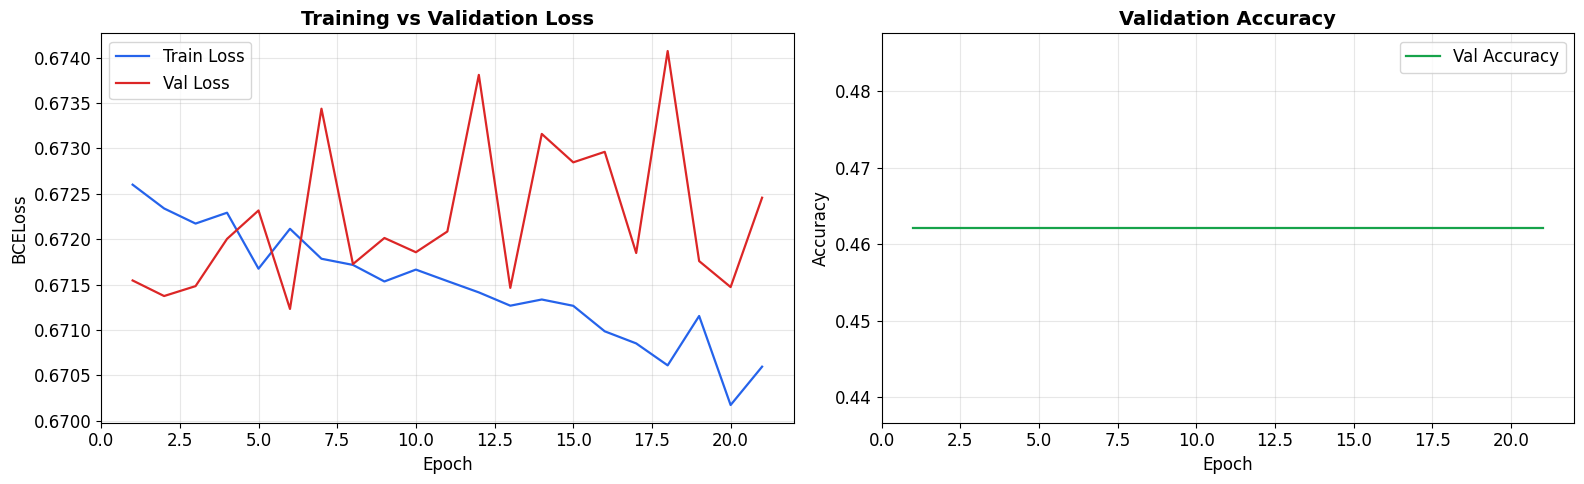

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# ── Loss ──
ax1.plot(epochs_range, history['train_loss'], label='Train Loss',
         color='#2563eb', linewidth=1.6)
ax1.plot(epochs_range, history['val_loss'], label='Val Loss',
         color='#dc2626', linewidth=1.6)
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCELoss')
ax1.legend(fontsize=12)

# ── Accuracy ──
ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy',
         color='#16a34a', linewidth=1.6)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

---
## 6 · Test-Set Evaluation

In [8]:
results = evaluate_lstm(model, X_test, y_test, device=device)

# Collapse detector
preds = (results['y_prob'] > 0.5).astype(int)
if preds.std() == 0:
    print('WARNING: model predicts a SINGLE class — collapse detected.')
else:
    print(f"Model predicts both classes: Up={preds.mean():.1%}  Down={(1-preds.mean()):.1%}")


══════════════════════════════════════════════════
  Test Evaluation
══════════════════════════════════════════════════
  Accuracy : 0.5498
  AUC-ROC  : 0.4959
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Down ↓       0.49      0.13      0.21       490
        Up ↑       0.56      0.89      0.69       605

    accuracy                           0.55      1095
   macro avg       0.52      0.51      0.45      1095
weighted avg       0.53      0.55      0.47      1095

Model predicts both classes: Up=87.9%  Down=12.1%


---
## 7 · ROC Curve

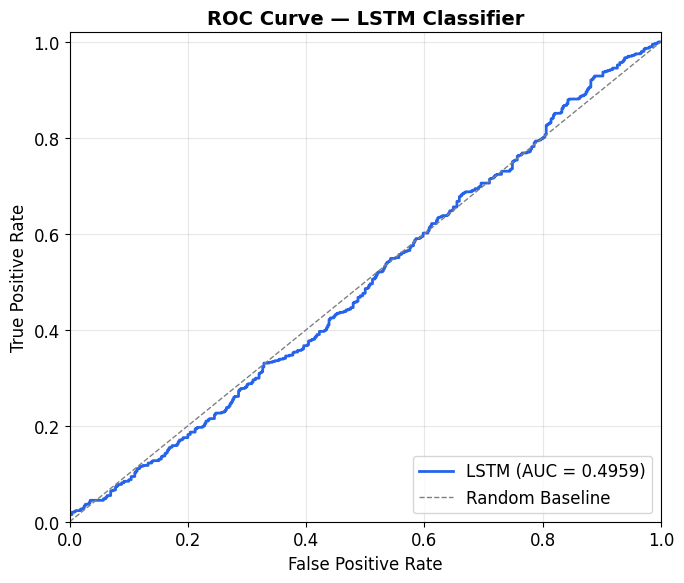

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(results['fpr'], results['tpr'],
        color='#2563eb', linewidth=2,
        label=f"LSTM (AUC = {results['auc_roc']:.4f})")
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
        label='Random Baseline')

ax.set_title('ROC Curve — LSTM Classifier', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

---
## 7.5 · Confusion Matrix

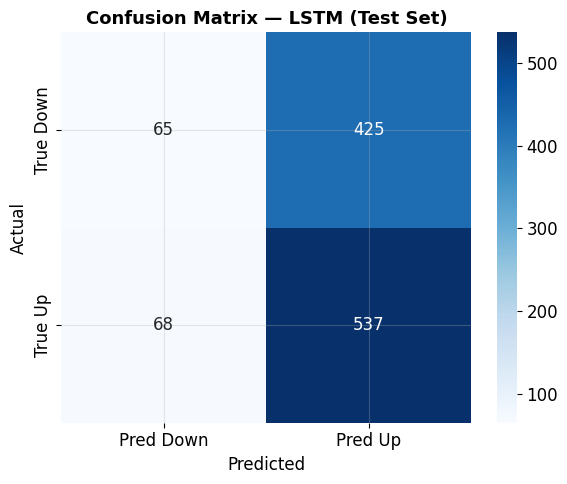

TN=65  FP=425  FN=68  TP=537


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
preds = (results['y_prob'] > 0.5).astype(int)
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Down', 'Pred Up'],
            yticklabels=['True Down', 'True Up'], ax=ax)
ax.set_title('Confusion Matrix — LSTM (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

---
## 8 · Final Metrics Summary

In [11]:
print('┌───────────────────────────────────┐')
print('│   LSTM  —  Final Test Metrics      │')
print('├───────────────────────────────────┤')
print(f"│   Accuracy :  {results['accuracy']:.4f}              │")
print(f"│   AUC-ROC  :  {results['auc_roc']:.4f}              │")
print('└───────────────────────────────────┘')

┌───────────────────────────────────┐
│   LSTM  —  Final Test Metrics      │
├───────────────────────────────────┤
│   Accuracy :  0.5498              │
│   AUC-ROC  :  0.4959              │
└───────────────────────────────────┘


---
## 9 · Per-Stock Evaluation (Optional)

Evaluate the combined-trained model on each stock individually to see per-ticker accuracy.

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score

per_stock_results = []

for ticker, (X_s_test, y_s_test) in per_stock_test.items():
    if len(X_s_test) == 0:
        continue
    
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_s_test, dtype=torch.float32).to(device)
        probs = torch.sigmoid(model(X_t)).cpu().numpy()
    
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_s_test, preds)
    try:
        auc = roc_auc_score(y_s_test, probs)
    except ValueError:
        auc = float('nan')
    
    per_stock_results.append({'Ticker': ticker, 'Accuracy': acc, 'AUC-ROC': auc,
                              'Test Samples': len(y_s_test)})
    print(f'  {ticker}  →  Acc: {acc:.4f}  |  AUC: {auc:.4f}  |  N={len(y_s_test)}')

pd.DataFrame(per_stock_results)

  AAPL  →  Acc: 0.5753  |  AUC: 0.4943  |  N=219
  MSFT  →  Acc: 0.5205  |  AUC: 0.4954  |  N=219
  GOOGL  →  Acc: 0.5982  |  AUC: 0.5380  |  N=219
  AMZN  →  Acc: 0.5297  |  AUC: 0.5215  |  N=219
  TSLA  →  Acc: 0.5251  |  AUC: 0.5177  |  N=219


,Ticker,Accuracy,AUC-ROC,Test Samples
0,AAPL,0.575342,0.494296,219
1,MSFT,0.520548,0.495391,219
2,GOOGL,0.598174,0.537984,219
3,AMZN,0.529680,0.521510,219
4,TSLA,0.525114,0.517699,219


---
### ✅ Model saved to `results/lstm_model.pth`
### Next Step → `03_finbert_sentiment.ipynb`